# Paper figures

This notebook generates only the figures used in the paper from the benchmark result files. All figures are saved directly into one output folder.

Expected input files:

- `results/tep/*.csv`
- `results/fcc/*.csv`
- `results/tep/diagnostics/perturbation_diagnostics_*.csv`
- `results/fcc/diagnostics/perturbation_diagnostics_*.csv`

The notebook uses only the original six AFC methods: `WDI-1NN`, `JAC-1NN`, `EAC-1NN`, `MBW-LR`, `ACM-SVM`, and `CASIM`.


In [1]:
from __future__ import annotations

from pathlib import Path
from fractions import Fraction
import re
import sys
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

try:
    from IPython.display import display
except Exception:
    display = print

# Robust repository-root detection for execution from the repository root or notebooks/.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

RESULT_DIRS = {
    "TEP": REPO_ROOT / "results" / "tep",
    "FCC": REPO_ROOT / "results" / "fcc",
}

# Single output folder: all paper figures are written directly here.
FIGURE_DIR = REPO_ROOT / "figures" / "paper"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SAVE_FORMATS = ("pdf", "png")
PNG_DPI = 450

METHOD_ORDER = [
    "WDI-1NN",
    "JAC-1NN",
    "EAC-1NN",
    "MBW-LR",
    "ACM-SVM",
    "CASIM",
]

PAPER_HEATMAP_SCENARIOS = [
    "missing_events",
    "spurious_events",
    "timing_uncertainty",
    "late_time_delay",
    "mixed_missing_spurious",
    "mixed_spurious_timing_late",
]

PAPER_HEATMAP_SCENARIO_LABELS = {
    "missing_events": "Missing events",
    "spurious_events": "Spurious events",
    "timing_uncertainty": "Timing uncertainty",
    "late_time_delay": "Pipeline-induced episode-start delay",
    "mixed_missing_spurious": "Mixed: missing + spurious",
    "mixed_spurious_timing_late": "Mixed: spurious + timing + delay",
}


def configure_matplotlib() -> None:
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "figure.titlesize": 10,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.minor.width": 0.4,
        "ytick.minor.width": 0.4,
        "grid.linewidth": 0.4,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


configure_matplotlib()
print(f"Repository root: {REPO_ROOT}")
print(f"Figure output folder: {FIGURE_DIR}")


Repository root: c:\Users\gianl\Documents\Code\afc-robustbench
Figure output folder: c:\Users\gianl\Documents\Code\afc-robustbench\figures\paper


## Helper functions and result loading

In [2]:
def slugify(value: str) -> str:
    value = str(value).strip().lower()
    value = re.sub(r"[^a-z0-9_\-]+", "_", value)
    return re.sub(r"_+", "_", value).strip("_")


def save_figure(fig: mpl.figure.Figure, stem: str | Path, formats: Iterable[str] = SAVE_FORMATS, dpi: int = PNG_DPI) -> None:
    """Save a figure directly into FIGURE_DIR under the given stem."""
    stem = Path(stem)
    if stem.parent == Path("."):
        out_base = FIGURE_DIR / stem.name
    else:
        # Keep direct output folder semantics: ignore nested parents and use only the filename stem.
        out_base = FIGURE_DIR / stem.name
    for fmt in formats:
        out = out_base.with_suffix(f".{fmt}")
        if fmt.lower() == "png":
            fig.savefig(out, dpi=dpi, bbox_inches="tight")
        else:
            fig.savefig(out, bbox_inches="tight")
        print(f"saved: {out}")


def severity_label(severity: float) -> str:
    value = 100.0 * float(severity)
    if np.isclose(value, round(value)):
        return f"{int(round(value))}"
    return f"{value:g}"


def progress_fraction_label(value: float, max_denominator: int = 12) -> str:
    value = float(value)
    if np.isclose(value, 0.0):
        return "0"
    if np.isclose(value, 1.0):
        return "1"
    frac = Fraction(value).limit_denominator(max_denominator)
    if frac.denominator == 1:
        return str(frac.numerator)
    return f"{frac.numerator}/{frac.denominator}"


def canonical_method_name(name: str) -> str:
    s = str(name).strip()
    s = re.sub(r"\bprefix\b", "", s, flags=re.IGNORECASE)
    s = re.sub(r"[-_ ]+", " ", s).strip()
    u = s.upper().replace(" ", "").replace("_", "-")

    if "WDI" in u:
        return "WDI-1NN"
    if "JAC" in u or "JACCARD" in u:
        return "JAC-1NN"
    if "EAC" in u:
        return "EAC-1NN"
    if "MBW" in u:
        return "MBW-LR"
    if "ACM" in u:
        return "ACM-SVM"
    if "CASIM" in u:
        return "CASIM"
    return str(name)


def keep_original_methods(df: pd.DataFrame) -> pd.DataFrame:
    if "method" not in df.columns:
        return df
    out = df.copy()
    out["method"] = out["method"].map(canonical_method_name)
    return out[out["method"].isin(METHOD_ORDER)].copy()


def load_result_tables(results_dir: Path, dataset_label: str) -> dict[str, pd.DataFrame]:
    results_dir = Path(results_dir)
    if not results_dir.exists():
        raise FileNotFoundError(f"Result directory does not exist: {results_dir}")

    table_names = [
        "raw_predictions",
        "degradation_profiles",
        "progress_auc",
        "scenario_scores",
        "overall_scores_by_fold",
        "overall_scores_summary",
    ]

    tables: dict[str, pd.DataFrame] = {}
    for name in table_names:
        path = results_dir / f"{name}.csv"
        if path.exists():
            df = pd.read_csv(path)
            df = keep_original_methods(df)
            if "scenario" in df.columns:
                df["scenario"] = df["scenario"].astype(str)
            if "severity" in df.columns:
                df["severity"] = df["severity"].astype(float)
            df["dataset_plot"] = dataset_label
            tables[name] = df

    if "progress_auc" not in tables:
        raise FileNotFoundError(f"Missing progress_auc.csv in {results_dir}")

    return tables


def load_all_results() -> dict[str, dict[str, pd.DataFrame]]:
    out = {}
    for dataset_label, folder in RESULT_DIRS.items():
        print(f"Loading {dataset_label}: {folder}")
        out[dataset_label] = load_result_tables(folder, dataset_label)
    return out


results = load_all_results()


Loading TEP: c:\Users\gianl\Documents\Code\afc-robustbench\results\tep
Loading FCC: c:\Users\gianl\Documents\Code\afc-robustbench\results\fcc


## Figure: perturbation impact on reconstructed alarm-series representations

saved: c:\Users\gianl\Documents\Code\afc-robustbench\figures\paper\paper_side_by_side_state_jaccard_heatmaps_tep_fcc.pdf
saved: c:\Users\gianl\Documents\Code\afc-robustbench\figures\paper\paper_side_by_side_state_jaccard_heatmaps_tep_fcc.png


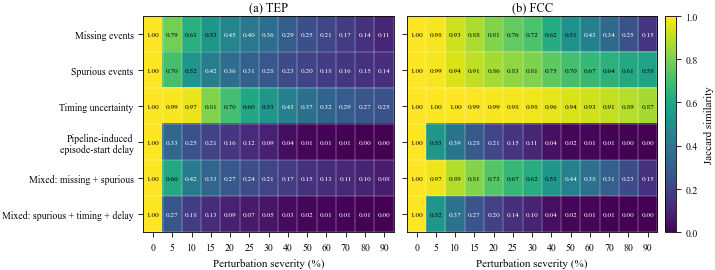

In [3]:
STATE_JACCARD_SCENARIOS = PAPER_HEATMAP_SCENARIOS
STATE_JACCARD_LABELS = {
    "missing_events": "Missing events",
    "spurious_events": "Spurious events",
    "timing_uncertainty": "Timing uncertainty",
    "late_time_delay": "Pipeline-induced\nepisode-start delay",
    "mixed_missing_spurious": "Mixed: missing + spurious",
    "mixed_spurious_timing_late": "Mixed: spurious + timing + delay",
}
STATE_JACCARD_METRIC_AGG = "state_active_cell_jaccard_mean"
STATE_JACCARD_METRIC_RAW = "state_active_cell_jaccard"
STATE_JACCARD_VARIANT = "repaired"


def load_diagnostic_table(dataset_label: str) -> pd.DataFrame:
    results_dir = Path(RESULT_DIRS[dataset_label])
    aggregated_path = results_dir / "diagnostics" / "perturbation_diagnostics_aggregated.csv"
    raw_path = results_dir / "diagnostics" / "perturbation_diagnostics_raw.csv"

    if aggregated_path.exists():
        df = pd.read_csv(aggregated_path)
    elif raw_path.exists():
        raw = pd.read_csv(raw_path)
        group_cols = ["scenario", "severity"]
        if "variant" in raw.columns:
            group_cols.append("variant")
        df = (
            raw.groupby(group_cols, as_index=False, observed=True)[STATE_JACCARD_METRIC_RAW]
            .mean()
            .rename(columns={STATE_JACCARD_METRIC_RAW: STATE_JACCARD_METRIC_AGG})
        )
    else:
        raise FileNotFoundError(
            f"Missing perturbation diagnostics for {dataset_label}. "
            "Run the corresponding 04_perturbation_diagnostics notebook first."
        )

    df["scenario"] = df["scenario"].astype(str)
    df["severity"] = df["severity"].astype(float)
    if "variant" in df.columns:
        df["variant"] = df["variant"].astype(str)
    return df


def state_jaccard_matrix(df: pd.DataFrame) -> tuple[pd.DataFrame, list[float]]:
    sub = df.copy()
    if "variant" in sub.columns:
        sub = sub[sub["variant"].str.lower() == STATE_JACCARD_VARIANT]

    available = set(sub["scenario"].unique())
    actual_order = []
    display_order = []
    for scenario in STATE_JACCARD_SCENARIOS:
        if scenario in available:
            actual_order.append(scenario)
            display_order.append(scenario)
        elif scenario == "late_time_delay" and "late_event_delay" in available:
            actual_order.append("late_event_delay")
            display_order.append("late_time_delay")

    sub = sub[sub["scenario"].isin(actual_order)]
    severity_order = sorted(sub["severity"].unique())
    mat = (
        sub.pivot_table(
            index="scenario",
            columns="severity",
            values=STATE_JACCARD_METRIC_AGG,
            aggfunc="mean",
        )
        .reindex(index=actual_order, columns=severity_order)
    )
    mat.index = display_order
    return mat, severity_order


def draw_state_jaccard_panel(ax, mat: pd.DataFrame, severities: list[float], title: str, show_ylabels: bool):
    data = mat.to_numpy(dtype=float)
    im = ax.imshow(data, aspect="auto", cmap="viridis", vmin=0.0, vmax=1.0, interpolation="nearest")
    ax.set_title(title, pad=4)
    ax.set_xticks(np.arange(len(severities)))
    ax.set_xticklabels([severity_label(s) for s in severities], rotation=0)
    ax.set_xlabel("Perturbation severity (%)")
    ax.set_yticks(np.arange(len(mat.index)))
    if show_ylabels:
        ax.set_yticklabels([STATE_JACCARD_LABELS.get(s, s) for s in mat.index])
    else:
        ax.set_yticklabels([])
    ax.set_xticks(np.arange(-0.5, len(severities), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(mat.index), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.35, alpha=0.65)
    ax.tick_params(which="minor", bottom=False, left=False)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=5.2, color="white" if val <= 0.5 else "black")
    return im


tep_diag = load_diagnostic_table("TEP")
fcc_diag = load_diagnostic_table("FCC")
tep_mat, tep_sev = state_jaccard_matrix(tep_diag)
fcc_mat, fcc_sev = state_jaccard_matrix(fcc_diag)

if tep_sev != fcc_sev:
    raise ValueError("TEP and FCC diagnostic severities differ; align before plotting.")

fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.75), constrained_layout=True)
im0 = draw_state_jaccard_panel(axes[0], tep_mat, tep_sev, "(a) TEP", show_ylabels=True)
im1 = draw_state_jaccard_panel(axes[1], fcc_mat, fcc_sev, "(b) FCC", show_ylabels=False)
cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.030, pad=0.015)
cbar.set_label("Jaccard similarity")

save_figure(fig, "paper_side_by_side_state_jaccard_heatmaps_tep_fcc")
plt.show()
plt.close(fig)


## Figures: progress-averaged robustness heatmaps

saved: c:\Users\gianl\Documents\Code\afc-robustbench\figures\paper\tep_progress_auc_performance_six_selected_scenarios.pdf
saved: c:\Users\gianl\Documents\Code\afc-robustbench\figures\paper\tep_progress_auc_performance_six_selected_scenarios.png


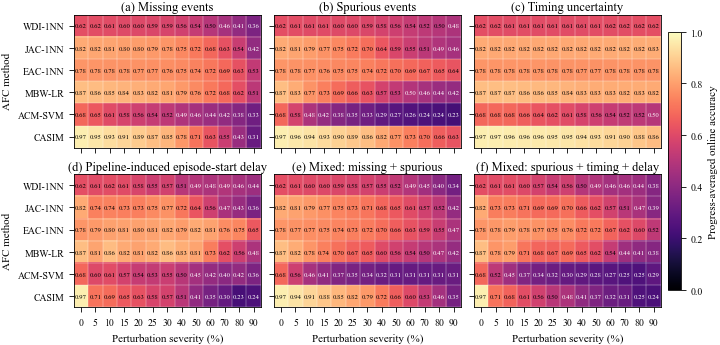

saved: c:\Users\gianl\Documents\Code\afc-robustbench\figures\paper\fcc_progress_auc_performance_six_selected_scenarios.pdf
saved: c:\Users\gianl\Documents\Code\afc-robustbench\figures\paper\fcc_progress_auc_performance_six_selected_scenarios.png


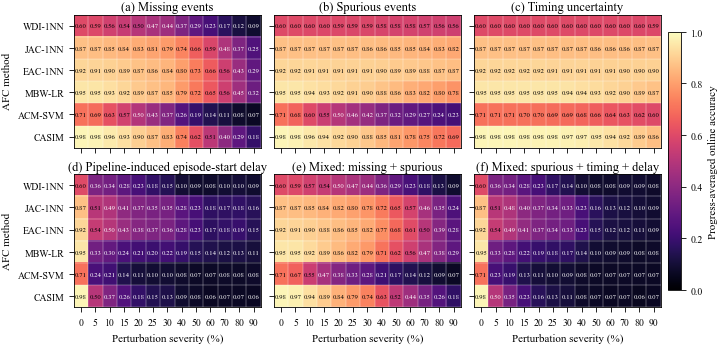

{'TEP': WindowsPath('c:/Users/gianl/Documents/Code/afc-robustbench/figures/paper/tep_progress_auc_performance_six_selected_scenarios'),
 'FCC': WindowsPath('c:/Users/gianl/Documents/Code/afc-robustbench/figures/paper/fcc_progress_auc_performance_six_selected_scenarios')}

In [4]:
def heatmap_color_settings():
    return "magma", 0.0, 1.0


def paper_heatmap_matrix(
    tables: dict[str, pd.DataFrame],
    scenario: str,
    method_order: list[str] = METHOD_ORDER,
) -> tuple[pd.DataFrame, list[float], list[str]]:
    df = tables["progress_auc"].copy()
    df = keep_original_methods(df)
    df["scenario"] = df["scenario"].astype(str)
    df["severity"] = df["severity"].astype(float)
    sub = df[df["scenario"] == str(scenario)].copy()
    if sub.empty:
        raise ValueError(f"No data found for scenario='{scenario}'.")

    agg = (
        sub.groupby(["method", "severity"], dropna=False)["progress_auc"]
        .mean()
        .reset_index(name="value")
    )
    severities = sorted(agg["severity"].unique())
    available_methods = list(dict.fromkeys(agg["method"].astype(str)))
    methods = [m for m in method_order if m in available_methods]
    methods += sorted(m for m in available_methods if m not in methods)
    mat = agg.pivot(index="method", columns="severity", values="value")
    mat = mat.reindex(index=methods, columns=severities)
    return mat, severities, methods


def plot_paper_six_heatmaps_for_dataset(
    tables: dict[str, pd.DataFrame],
    dataset_label: str,
    scenarios: list[str] = PAPER_HEATMAP_SCENARIOS,
    annotate: bool = True,
) -> mpl.figure.Figure:
    available = set(map(str, tables["progress_auc"]["scenario"].unique()))
    scenarios = [s for s in scenarios if s in available]
    if len(scenarios) != 6:
        raise ValueError(f"Expected six available scenarios, found {len(scenarios)}: {scenarios}")

    cmap, vmin, vmax = heatmap_color_settings()
    cbar_label = "Progress-averaged online accuracy"

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(7.25, 3.50),
        squeeze=False,
        constrained_layout=True,
    )

    ims = []
    for idx, scenario in enumerate(scenarios):
        row, col = divmod(idx, 3)
        ax = axes[row, col]
        mat, severities, methods = paper_heatmap_matrix(tables, scenario=scenario)
        data = mat.to_numpy(dtype=float)

        im = ax.imshow(data, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
        ims.append(im)

        ax.set_title(f"({chr(97 + idx)}) {PAPER_HEATMAP_SCENARIO_LABELS.get(scenario, scenario)}", pad=3)
        ax.set_xticks(np.arange(len(severities)))
        ax.set_xticklabels([severity_label(s) for s in severities], rotation=0)

        ax.set_yticks(np.arange(len(methods)))
        if col == 0:
            ax.set_yticklabels(methods)
            ax.set_ylabel("AFC method")
        else:
            ax.set_yticklabels([])
            ax.set_ylabel("")

        if row == 1:
            ax.set_xlabel("Perturbation severity (%)")
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

        ax.set_xticks(np.arange(-0.5, len(severities), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(methods), 1), minor=True)
        ax.grid(which="minor", color="white", linestyle="-", linewidth=0.35, alpha=0.65)
        ax.tick_params(which="minor", bottom=False, left=False)

        if annotate:
            for i in range(data.shape[0]):
                for j in range(data.shape[1]):
                    val = data[i, j]
                    if np.isfinite(val):
                        ax.text(
                            j,
                            i,
                            f"{val:.2f}",
                            ha="center",
                            va="center",
                            fontsize=4.9,
                            color="white" if val <= 0.50 else "black",
                        )

    cbar = fig.colorbar(ims[0], ax=axes.ravel().tolist(), fraction=0.022, pad=0.012)
    cbar.set_label(cbar_label)
    return fig


paper_heatmap_paths = {}
for dataset_label in ["TEP", "FCC"]:
    fig = plot_paper_six_heatmaps_for_dataset(
        tables=results[dataset_label],
        dataset_label=dataset_label,
        scenarios=PAPER_HEATMAP_SCENARIOS,
        annotate=True,
    )
    out_stem = f"{slugify(dataset_label)}_progress_auc_performance_six_selected_scenarios"
    save_figure(fig, out_stem)
    paper_heatmap_paths[dataset_label] = FIGURE_DIR / out_stem
    plt.show()
    plt.close(fig)

paper_heatmap_paths


## Figure: combined Pareto comparison

,method,clean_progress_auc_mean,R_avg_mean,R_min_mean
0,WDI-1NN,0.610281,0.489077,0.341480
1,JAC-1NN,0.845438,0.680557,0.457432
2,EAC-1NN,0.848573,0.726594,0.506757
3,MBW-LR,0.909958,0.704073,0.392522
4,ACM-SVM,0.694688,0.418906,0.222264
5,CASIM,0.973667,0.687978,0.316277


saved: c:\Users\gianl\Documents\Code\afc-robustbench\figures\paper\pareto_combined_clean_accuracy_vs_ravg_rmin_mean_over_datasets_single_legend.pdf
saved: c:\Users\gianl\Documents\Code\afc-robustbench\figures\paper\pareto_combined_clean_accuracy_vs_ravg_rmin_mean_over_datasets_single_legend.png


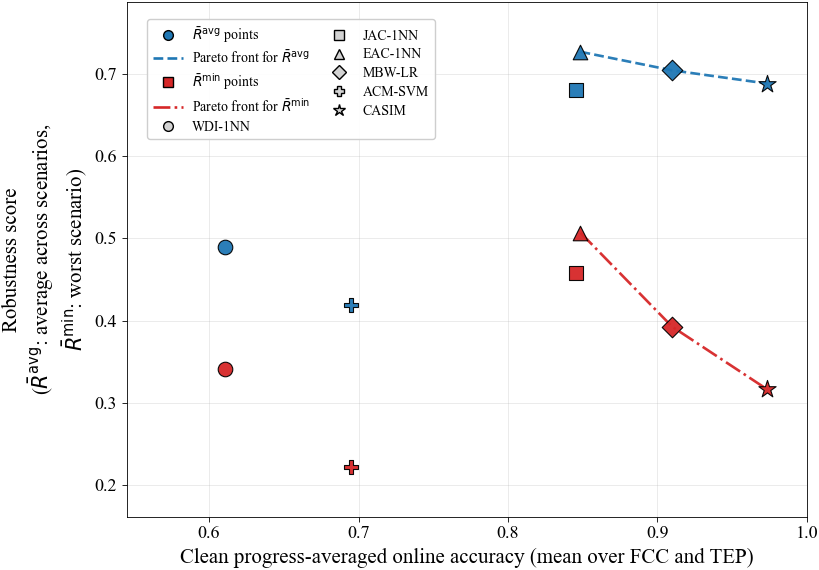

In [5]:
def is_mixed_scenario(series: pd.Series) -> pd.Series:
    return series.astype(str).str.contains("mixed", case=False, regex=False)


def integrate_over_severity(group: pd.DataFrame, value_col: str = "progress_auc") -> float:
    g = group[["severity", value_col]].dropna().copy()
    g["severity"] = g["severity"].astype(float)
    g = g.groupby("severity", as_index=False)[value_col].mean().sort_values("severity")
    if g.empty:
        return np.nan
    if len(g) == 1:
        return float(g[value_col].iloc[0])
    x = g["severity"].to_numpy(dtype=float)
    y = g[value_col].to_numpy(dtype=float)
    span = float(x[-1] - x[0])
    if span <= 0:
        return float(np.mean(y))
    trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    return float(trapz(y, x) / span)


def build_datasetwise_pareto_summary(result_tables: dict[str, dict[str, pd.DataFrame]]) -> pd.DataFrame:
    rows = []
    for dataset_label, tables in result_tables.items():
        df = tables["progress_auc"].copy()
        df = keep_original_methods(df)
        df["dataset_plot"] = str(dataset_label).upper()
        df["scenario"] = df["scenario"].astype(str)
        df["severity"] = df["severity"].astype(float)
        if "fold" not in df.columns:
            df["fold"] = 0
        if "repeat" not in df.columns:
            df["repeat"] = 0

        df_robustness = df.loc[~is_mixed_scenario(df["scenario"])].copy()

        clean = (
            df_robustness[np.isclose(df_robustness["severity"], 0.0)]
            .groupby(["dataset_plot", "fold", "repeat", "method"], as_index=False, dropna=False)["progress_auc"]
            .mean()
            .rename(columns={"progress_auc": "clean_progress_auc"})
        )

        scenario_rows = []
        for keys, group in df_robustness.groupby(["dataset_plot", "fold", "repeat", "method", "scenario"], dropna=False):
            dataset_i, fold_i, repeat_i, method_i, scenario_i = keys
            scenario_rows.append({
                "dataset_plot": dataset_i,
                "fold": fold_i,
                "repeat": repeat_i,
                "method": method_i,
                "scenario": scenario_i,
                "scenario_score": integrate_over_severity(group, value_col="progress_auc"),
            })

        scenario_scores = pd.DataFrame(scenario_rows)
        robustness = (
            scenario_scores.groupby(["dataset_plot", "fold", "repeat", "method"], as_index=False, dropna=False)["scenario_score"]
            .agg(R_avg="mean", R_min="min")
        )
        rows.append(clean.merge(robustness, on=["dataset_plot", "fold", "repeat", "method"], how="inner"))

    by_fold = pd.concat(rows, ignore_index=True)
    datasetwise = (
        by_fold.groupby(["dataset_plot", "method"], as_index=False)
        .agg(
            clean_progress_auc_mean=("clean_progress_auc", "mean"),
            R_avg_mean=("R_avg", "mean"),
            R_min_mean=("R_min", "mean"),
        )
    )
    order = {method: i for i, method in enumerate(METHOD_ORDER)}
    datasetwise["method_order"] = datasetwise["method"].map(order)
    return datasetwise.sort_values(["dataset_plot", "method_order"]).drop(columns="method_order").reset_index(drop=True)


def pareto_front_maximize(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    pts = df[[x_col, y_col, "method"]].dropna().copy()
    pts = pts.sort_values([x_col, y_col], ascending=[False, False])
    chosen = []
    best_y = -np.inf
    for _, row in pts.iterrows():
        y = float(row[y_col])
        if y > best_y + 1e-12:
            chosen.append(row)
            best_y = y
    return pd.DataFrame(chosen).sort_values(x_col, ascending=True)


def nice_limits(values, pad_fraction=0.10, lower_bound=0.0, upper_bound=1.0):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return lower_bound, upper_bound
    lo = float(vals.min())
    hi = float(vals.max())
    span = hi - lo if hi > lo else 0.1
    return max(lower_bound, lo - pad_fraction * span), min(upper_bound, hi + pad_fraction * span)


datasetwise_pareto_df = build_datasetwise_pareto_summary(results)
combined_pareto_df = (
    datasetwise_pareto_df.groupby("method", as_index=False)
    .agg(
        clean_progress_auc_mean=("clean_progress_auc_mean", "mean"),
        R_avg_mean=("R_avg_mean", "mean"),
        R_min_mean=("R_min_mean", "mean"),
    )
)
order = {method: i for i, method in enumerate(METHOD_ORDER)}
combined_pareto_df["method_order"] = combined_pareto_df["method"].map(order)
combined_pareto_df = combined_pareto_df.sort_values("method_order").drop(columns="method_order").reset_index(drop=True)

display(combined_pareto_df)

METHOD_MARKERS = {
    "WDI-1NN": "o",
    "JAC-1NN": "s",
    "EAC-1NN": "^",
    "MBW-LR": "D",
    "ACM-SVM": "P",
    "CASIM": "*",
}
METRIC_COLORS = {"R_avg_mean": "#1f77b4", "R_min_mean": "#d62728"}
METRIC_LINESTYLES = {"R_avg_mean": "--", "R_min_mean": "-."}
METRIC_LABELS = {"R_avg_mean": r"$\bar{R}^{\mathrm{avg}}$", "R_min_mean": r"$\bar{R}^{\mathrm{min}}$"}

fig, ax = plt.subplots(figsize=(8.4, 5.9))
x_col = "clean_progress_auc_mean"

for y_col in ["R_avg_mean", "R_min_mean"]:
    for _, row in combined_pareto_df.iterrows():
        method = row["method"]
        ax.scatter(
            row[x_col],
            row[y_col],
            s=110 if method != "CASIM" else 170,
            marker=METHOD_MARKERS.get(method, "o"),
            c=METRIC_COLORS[y_col],
            edgecolors="black",
            linewidths=0.8,
            alpha=0.95,
            zorder=3,
        )

    front = pareto_front_maximize(combined_pareto_df, x_col=x_col, y_col=y_col)
    ax.plot(
        front[x_col].to_numpy(),
        front[y_col].to_numpy(),
        linestyle=METRIC_LINESTYLES[y_col],
        linewidth=1.9,
        color=METRIC_COLORS[y_col],
        alpha=0.95,
        zorder=2,
    )

all_x = combined_pareto_df[x_col].to_numpy()
all_y = np.concatenate([combined_pareto_df["R_avg_mean"].to_numpy(), combined_pareto_df["R_min_mean"].to_numpy()])
x_lo, x_hi = nice_limits(all_x, pad_fraction=0.18)
y_lo, y_hi = nice_limits(all_y, pad_fraction=0.12)
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)

ax.set_xlabel("Clean progress-averaged online accuracy (mean over FCC and TEP)", fontsize=15)
ax.set_ylabel(
    "Robustness score\n"
    r"($\bar{R}^{\mathrm{avg}}$: average across scenarios,"
    "\n"
    r"$\bar{R}^{\mathrm{min}}$: worst scenario)",
    fontsize=15,
)
ax.tick_params(axis="both", labelsize=13)
ax.grid(True, linewidth=0.5, alpha=0.35)

series_handles = [
    Line2D([0], [0], marker="o", linestyle="None", markerfacecolor=METRIC_COLORS["R_avg_mean"], markeredgecolor="black", markersize=7, label=rf"{METRIC_LABELS['R_avg_mean']} points"),
    Line2D([0], [0], linestyle=METRIC_LINESTYLES["R_avg_mean"], color=METRIC_COLORS["R_avg_mean"], linewidth=1.9, label=rf"Pareto front for {METRIC_LABELS['R_avg_mean']}"),
    Line2D([0], [0], marker="s", linestyle="None", markerfacecolor=METRIC_COLORS["R_min_mean"], markeredgecolor="black", markersize=7, label=rf"{METRIC_LABELS['R_min_mean']} points"),
    Line2D([0], [0], linestyle=METRIC_LINESTYLES["R_min_mean"], color=METRIC_COLORS["R_min_mean"], linewidth=1.9, label=rf"Pareto front for {METRIC_LABELS['R_min_mean']}"),
]
method_handles = [
    Line2D([0], [0], marker=METHOD_MARKERS[m], linestyle="None", markerfacecolor="lightgray", markeredgecolor="black", color="black", markersize=7 if m != "CASIM" else 9, label=m)
    for m in METHOD_ORDER
]
ax.legend(
    handles=series_handles + method_handles,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    frameon=True,
    framealpha=0.95,
    fontsize=10,
    borderpad=0.4,
    labelspacing=0.35,
    handlelength=2.2,
    handletextpad=0.6,
    ncol=2,
    columnspacing=1.0,
)

fig.tight_layout()
save_figure(fig, "pareto_combined_clean_accuracy_vs_ravg_rmin_mean_over_datasets_single_legend")
plt.show()
plt.close(fig)


## Figure: example degradation profile

saved: c:\Users\gianl\Documents\Code\afc-robustbench\figures\paper\fcc_acm_svm_missing_events_degradation_profile.pdf
saved: c:\Users\gianl\Documents\Code\afc-robustbench\figures\paper\fcc_acm_svm_missing_events_degradation_profile.png


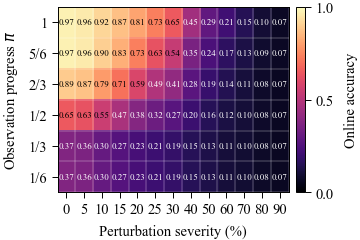

In [6]:
def load_raw_predictions(result_dirs: dict[str, Path]) -> pd.DataFrame:
    frames = []
    for dataset_label, result_dir in result_dirs.items():
        path = Path(result_dir) / "raw_predictions.csv"
        if not path.exists():
            raise FileNotFoundError(f"Missing raw predictions file: {path}")
        df = pd.read_csv(path)
        df["dataset_plot"] = dataset_label
        frames.append(df)

    raw = pd.concat(frames, ignore_index=True)
    required = {"dataset_plot", "fold", "repeat", "method", "scenario", "severity", "draw", "progress", "correct"}
    missing = required.difference(raw.columns)
    if missing:
        raise ValueError(f"raw_predictions.csv is missing required columns: {sorted(missing)}")

    raw = keep_original_methods(raw)
    raw["scenario"] = raw["scenario"].astype(str)
    raw["severity"] = raw["severity"].astype(float)
    raw["progress"] = raw["progress"].astype(float)
    raw["correct"] = raw["correct"].astype(float)
    return raw


raw_predictions = load_raw_predictions(RESULT_DIRS)
profile_by_unit = (
    raw_predictions.groupby(
        ["dataset_plot", "fold", "repeat", "draw", "method", "scenario", "severity", "progress"],
        as_index=False,
        observed=True,
    )["correct"]
    .mean()
    .rename(columns={"correct": "score"})
)


def build_profile_matrix(dataset_label: str, method: str, scenario: str) -> tuple[pd.DataFrame, list[float], list[float]]:
    sub = profile_by_unit[
        (profile_by_unit["dataset_plot"] == dataset_label)
        & (profile_by_unit["method"] == method)
        & (profile_by_unit["scenario"] == scenario)
    ].copy()
    if sub.empty:
        raise ValueError(f"No profile data for {dataset_label}, {method}, {scenario}")

    agg = sub.groupby(["progress", "severity"], as_index=False, observed=True)["score"].mean()
    progress_values = sorted(agg["progress"].unique())
    severity_values = sorted(agg["severity"].unique())
    mat = agg.pivot(index="progress", columns="severity", values="score").reindex(index=progress_values, columns=severity_values)
    return mat, progress_values, severity_values


def plot_degradation_profile(dataset_label: str, method: str, scenario: str) -> mpl.figure.Figure:
    mat, progress_values, severity_values = build_profile_matrix(dataset_label, method, scenario)
    data = mat.to_numpy(dtype=float)
    masked = np.ma.masked_invalid(data)

    with mpl.rc_context({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": 10.5,
        "axes.labelsize": 10.5,
        "xtick.labelsize": 10.5,
        "ytick.labelsize": 10.5,
        "axes.linewidth": 0.7,
        "xtick.major.width": 0.7,
        "ytick.major.width": 0.7,
        "xtick.major.size": 4.0,
        "ytick.major.size": 4.0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }):
        fig, ax = plt.subplots(figsize=(3.65, 2.45), constrained_layout=True)
        im = ax.imshow(masked, aspect="auto", origin="lower", cmap="magma", vmin=0.0, vmax=1.0, interpolation="nearest")

        ax.set_xlabel("Perturbation severity (%)", labelpad=5)
        ax.set_ylabel(r"Observation progress $\pi$", labelpad=6)
        ax.set_xticks(np.arange(len(severity_values)))
        ax.set_xticklabels([severity_label(s) for s in severity_values], rotation=0)
        ax.set_yticks(np.arange(len(progress_values)))
        ax.set_yticklabels([progress_fraction_label(p) for p in progress_values])

        ax.set_xticks(np.arange(-0.5, len(severity_values), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(progress_values), 1), minor=True)
        ax.grid(which="minor", color="white", linestyle="-", linewidth=0.35, alpha=0.65)
        ax.tick_params(which="minor", bottom=False, left=False)

        for spine in ax.spines.values():
            spine.set_linewidth(0.7)

        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                value = data[i, j]
                if np.isfinite(value):
                    ax.text(
                        j,
                        i,
                        f"{value:.2f}",
                        ha="center",
                        va="center",
                        fontsize=6.5,
                        color="white" if value <= 0.50 else "black",
                    )

        cbar = fig.colorbar(im, ax=ax, fraction=0.055, pad=0.03)
        cbar.set_label("Online accuracy", fontsize=10.5, labelpad=8)
        cbar.set_ticks([0.0, 0.5, 1.0])
        cbar.ax.tick_params(labelsize=10.5, width=0.7, length=4.0)
        return fig


fig = plot_degradation_profile("FCC", "ACM-SVM", "missing_events")
save_figure(fig, "fcc_acm_svm_missing_events_degradation_profile")
plt.show()
plt.close(fig)
